In [1]:
from readers.NSIDataReader import NSIDataReader
from cil.processors import Slicer
import math
from pathlib import Path, PureWindowsPath
from cil.framework import AcquisitionData, AcquisitionGeometry, ImageGeometry
from cil.utilities.display import show2D, show_geometry, show_system_positions
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from cil.plugins.astra import FBP
from cil.optimisation.algorithms import CGLS
from cil.processors import TransmissionAbsorptionConverter
from cil.utilities.jupyter import islicer
from cil.plugins.astra import ProjectionOperator
print(NSIDataReader)
#%matplotlib widget

<class 'readers.NSIDataReader.NSIDataReader'>


In [2]:
#   Copyright 2025 UKRI-STFC
#   Copyright 2025 University of Manchester

#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at

#   http://www.apache.org/licenses/LICENSE-2.0

#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
#
# Authors:

from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.io.TIFF import TIFFStackReader
import warnings
import numpy as np
import os
    
        
class NSIDataReader_(object):
    
    def __init__(self, file_name=None, positions_path = None, roi=None, num_proj_subset=None):
        """
        file_name: Should be in the file format .nsipro
        num_proj_subset: number of projections to use starting from the first projection.
            TODO - Extend this to a slice object.
        """
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.positions_path = positions_path
        
        if file_name is not None:
            self.set_up(file_name=file_name, num_proj_subset=num_proj_subset, roi=roi)
        self.roi = roi
    

    @staticmethod
    def load_positions(txt_path):
        coords = []

        with open(txt_path, 'r') as f:
            for line in f:
                line = line.strip()

                # stop when zero-position section begins
                if line.lower().startswith('# === zero position'):
                    break

                if not line or line.startswith('#'):
                    continue

                parts = line.split()

                if len(parts) < 3:
                    continue

                try:
                    x = float(parts[0])
                    y = float(parts[1])
                    coords.append([x, y])
                except ValueError:
                    continue

        return np.array(coords)


    @staticmethod
    def parse_nsipro(file_name):
        with open(file_name, 'r') as f:
            text = f.read()
        lines = [line.rstrip() for line in text.splitlines() if line.strip()]
        root = {}
        stack = [(root, None)]  # (current_dict, current_key)
        
        for line in lines:
            indent = len(line) - len(line.lstrip())
            content = line.strip()
            
            # Adjust stack based on indentation
            while len(stack) > indent // 2 + 1:  # assuming 2 spaces per indent
                stack.pop()
            
            current_dict, current_key = stack[-1]
            
            if content.startswith("</"):  # closing tag
                continue
            
            if content.startswith("<") and ">" in content:
                # Extract tag and value
                tag = content[1:content.find(">")]
                value = content[content.find(">")+1:].strip()
                
                if value:  # tag with value
                    current_dict[tag] = value
                else:  # tag without value (container)
                    if tag in current_dict:
                        # Convert to list if repeated
                        if not isinstance(current_dict[tag], list):
                            current_dict[tag] = [current_dict[tag]]
                        new_dict = {}
                        current_dict[tag].append(new_dict)
                    else:
                        new_dict = {}
                        current_dict[tag] = new_dict
                    stack.append((new_dict, tag))
        
        return root
            
    def set_up(self,
                file_name=None,
                  num_proj_subset=None,
                  roi={'projection': -1, 'horizontal': -1, 'vertical': -1},):
        self._metadata = self.parse_nsipro(file_name)['NSI Reconstruction Project']
        self.file_name = file_name
        self.num_proj_subset = num_proj_subset
        self.tiff_directory_path = (Path(file_name).parent / PureWindowsPath(self._metadata['Object Radiograph']['file'])).parent

        if self.file_name == None:
            raise Exception('Path to file is required.')
        
        if not(os.path.isfile(self.file_name)):
            raise Exception('File\n {}\n does not exist.'.format(self.file_name))
        
        self._height_per_rev = float(self._metadata['VorteX']['pitch'])
        self._revs = int(self._metadata['VorteX']['revolutions'])
        self._num_proj = int(self._metadata['Object Radiograph']['number'])
        self._angle_step = self._num_proj / (360 * self._revs)
        self._proj_per_rev = self._num_proj / self._revs
        self._height_per_step = self._height_per_rev / self._proj_per_rev



        positions = self.load_positions(self.positions_path)


        self._pixel_num_w = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['width pixels'])
        self._pixel_num_h = int(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['height pixels'])
        microns_to_mm = 0.001
        self._pixel_size_w = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
        self._pixel_size_h = microns_to_mm * float(self._metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])
        self._src_to_det = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
        self._src_to_obj = float(self._metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])

        self._obj_to_det = self._src_to_obj - self._src_to_det

        self.N = self._num_proj
        self._src_pos = np.zeros((self.N,3))
        self._det_pos = np.zeros((self.N,3))
        self._det_x = np.zeros((self.N,3))
        self._det_y = np.zeros((self.N,3))

        def get_rot_mat(ang):
            ang_rad = np.deg2rad(ang)
            c = np.cos(ang_rad)
            s = np.sin(ang_rad)
            Rz = np.array([
                [ c, -s, 0],
                [ s,  c, 0],
                [ 0,  0, 1]
            ])
            return Rz

        self._src_pos[0] = [self._src_to_obj, 0., 0.]
        self._det_pos[0] = [self._obj_to_det, 0., 0.]
        self._det_x[0] = [0., 1, 0]
        self._det_y[0] = [0., 0., 1]
        for i in range(1,self.N):
            h = i * self._height_per_step
            Rz = get_rot_mat(self._angle_step)
            
            self._src_pos[i] = Rz @ self._src_pos[i-1]
            self._det_pos[i] = Rz @ self._det_pos[i-1]
            self._det_x[i] = Rz @ self._det_x[i-1]
            self._det_y[i] = Rz @ self._det_y[i-1]

            self._src_pos[i,2] = h
            self._det_pos[i,2] = h


        det_pos = np.asarray(self._det_pos)
        det_x = np.asarray(self._det_x)
        det_y = np.asarray(self._det_y)

        du = positions[:, 0][:, None]  # (N,1)
        dv = positions[:, 1][:, None]  # (N,1)

        print(du.shape)
        print(det_pos.shape)
        corrected_pos = det_pos + du * det_x + dv * det_y
        self._det_pos = corrected_pos

        self._ag = AcquisitionGeometry.create_Cone3D_Flex(self._src_pos, self._det_pos, self._det_x, self._det_y)
        self._ag = self._ag.set_panel((self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h))
        self._ag.set_labels(['projection', 'vertical', 'horizontal'])


        N_full  = int(self._metadata["Object Radiograph"]["number"])
        Ny_full = int(self._metadata["CT Project Configuration"]["Technique Configuration"]["Detector"]["height pixels"])
        Nx_full = int(self._metadata["CT Project Configuration"]["Technique Configuration"]["Detector"]["width pixels"])
        self._roi_par = [
            [0, N_full, 1],     # projection
            [0, Ny_full, 1],    # vertical
            [0, Nx_full, 1]     # horizontal
        ]

        for key in roi.keys():
            if key == 'projection':
                idx = 0
            elif key == 'vertical':
                idx = 1
            elif key == 'horizontal':
                idx = 2
            if roi[key] != -1:
                for i in range(2):
                    if roi[key][i] != None:
                        if roi[key][i] >= 0:
                            self._roi_par[idx][i] = roi[key][i]
                        else:
                            self._roi_par[idx][i] = self._roi_par[idx][1]+roi[key][i]
                if len(roi[key]) > 2:
                    if roi[key][2] != None:
                        if roi[key][2] > 0:
                            self._roi_par[idx][2] = roi[key][2]
                        else:
                            raise Exception("Negative step is not allowed")
        
        print(self._roi_par)
        # -------------------------------
        # Build full geometry (unsliced)
        # -------------------------------
        print(roi)
        processor = Slicer(roi)
        processor.set_input(self._ag)
        geometry_sliced = processor.get_output()
        self._ag = geometry_sliced


    def get_geometry(self, index=None):
        '''
        Return AcquisitionGeometry object.
        index=None returns the flex geometry
        while setting it to an integer returns the geometry at that specific angle.
        '''
        if index is None:
            return self._ag
        
        ag = AcquisitionGeometry.create_Cone3D(
            self._src_pos[index],
            self._det_pos[index],
            self._det_x[index],
            self._det_y[index],
        ).set_panel(
            (self._pixel_num_w, self._pixel_num_h), (self._pixel_size_w, self._pixel_size_h)
        ).set_angles([index*self._angle_step])
        return ag
    
    def get_roi(self):
        '''returns the roi'''
        roi = self._roi_par[:]
        if self._ag.dimension == '2D':
            roi.pop(1)

        roidict = {}
        for i,el in enumerate(roi):
            # print (i, el)
            roidict['axis_{}'.format(i)] = tuple(el)
        return roidict

    def read(self):

        obj_rad = self._metadata["Object Radiograph"]

        raw_field = obj_rad["file"].replace("\\", "/")
        tiff_folder = raw_field.split("/")[0]

        cfg_dir = os.path.dirname(self.file_name)
        tiff_dir = os.path.join(cfg_dir, tiff_folder)

        roi = self.roi
        label_to_axis = {
            'vertical': 'axis_2',
            'projection': 'axis_0',
            'horizontal': 'axis_1'
        }
        roi_axis = {label_to_axis[k]: v for k, v in roi.items()}


        reader = TIFFStackReader()
        reader.set_up(
            file_name=tiff_dir,
            roi=roi_axis,   # MUST match geometry slicing
        )
        print(roi_axis)

        print(self._ag)
        ad = reader.read_as_AcquisitionData(self._ag)

        return ad
    


    def get_image_geometry(self, full_cover=True, remove_slices_per_side = 0):
        magnification = np.mean(self._ag.magnification)

        detector_height = self._pixel_num_h*self._pixel_size_h

        start_proj = 0
        end_proj = self._num_proj

        for key in self.roi.keys():
            if key == 'projection':
                start_proj = self.roi[key][0]
                end_proj = self.roi[key][1]

        N_roi_revolutions = (end_proj - start_proj)/self._num_proj * self._revs
        total_vertical_movement = self._revs*self._height_per_rev
        middle_height = total_vertical_movement * ((end_proj+start_proj)/2)/self._num_proj


        print('total height   ,   middle height ')
        print(total_vertical_movement, middle_height)

        extra_pixels_per_rev = self._height_per_rev/(detector_height/magnification) * self._pixel_num_h  # Number of pixels, we move up every rev
        print('extra pixels per rev')
        print(extra_pixels_per_rev)

        vertical_pixels = int(self._pixel_num_h + extra_pixels_per_rev * N_roi_revolutions)
        print('N_roi_revolutins')
        print(N_roi_revolutions)  
        if full_cover:
            vertical_pixels = int(vertical_pixels - 2* extra_pixels_per_rev)

        vertical_pixels = vertical_pixels - 2*remove_slices_per_side
        vertical_pixels = 100
        ig = ImageGeometry(
            self._pixel_num_w-500, self._pixel_num_w-500, vertical_pixels, # voxel nums
            self._pixel_size_w/magnification, self._pixel_size_w/magnification, self._pixel_size_w/magnification, # voxel sizes
            center_z=middle_height
        )
        return ig



    def load_projections(self):
        '''alias of read for backward compatibility'''
        return self.read()



(4320, 1)
(4320, 3)
[[500, 860, 1], [0, 1536, 1], [0, 1536, 1]]
{'projection': (500, 860, 1)}
New geometry:  Per-projection 3D Cone-beam tomography
System configuration:
	Number of projections: 360
	Source positions 0-9: [[-196.90942597, 165.22662671,  20.84843171],
 [-199.76303795, 161.76491856,  20.89012858],
 [-202.55580018, 158.25393525,  20.93182544],
 [-205.28686195, 154.69474626,  20.9735223 ],
 [-207.95539135, 151.08843575,  21.01521917],
 [-210.56057553, 147.43610223,  21.05691603],
 [-213.10162091, 143.73885826,  21.09861289],
 [-215.57775348, 139.99783003,  21.14030976],
 [-217.98821897, 136.21415711,  21.18200662],
 [-220.33228314, 132.38899204,  21.22370348]]
	Detector positions 0-9: [[ 766.40828541,-644.67669501,  16.83171671],
 [ 777.14412476,-631.69505967,  16.23400658],
 [ 787.52589733,-618.70709705,  16.56607844],
 [ 798.74547544,-604.14992287,  16.5970023 ],
 [ 808.90255153,-590.48281267,  17.41749517],
 [ 819.21927087,-576.0833929 ,  18.32807203],
 [ 828.71368776,-5

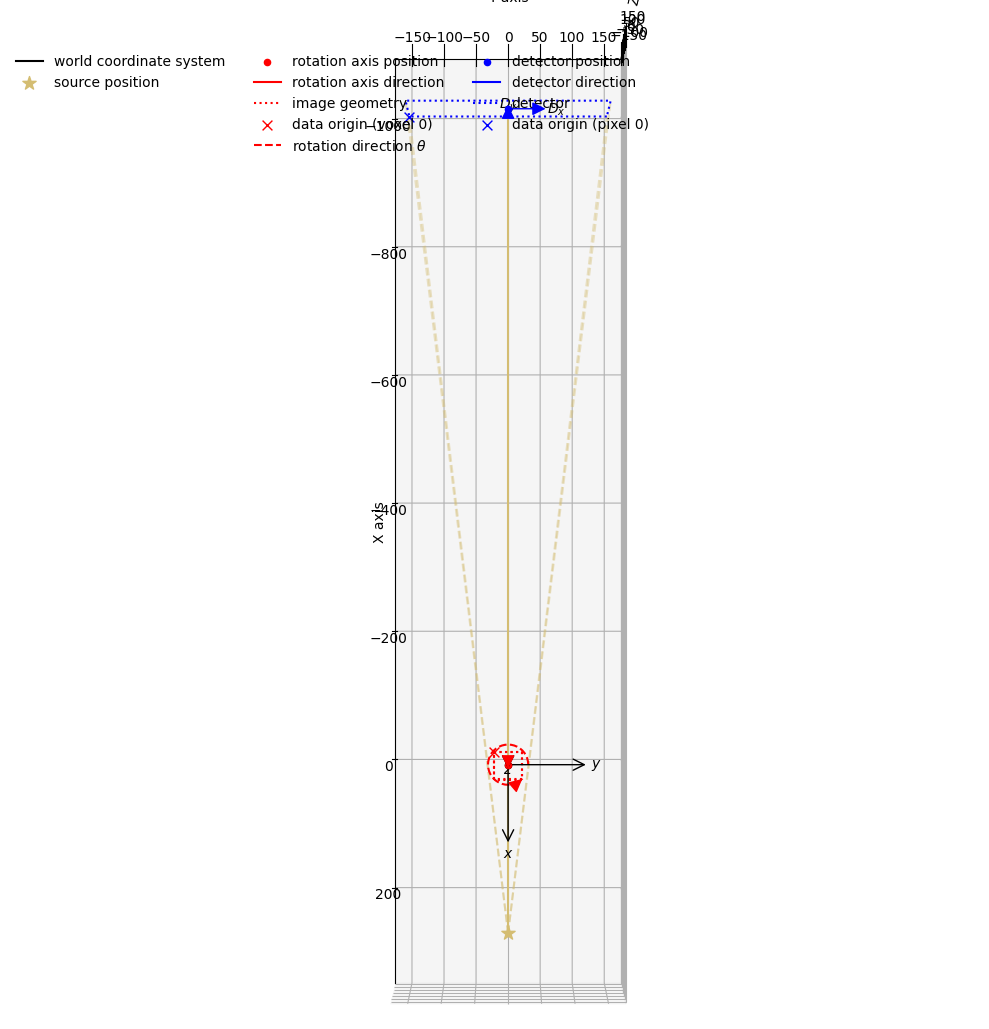

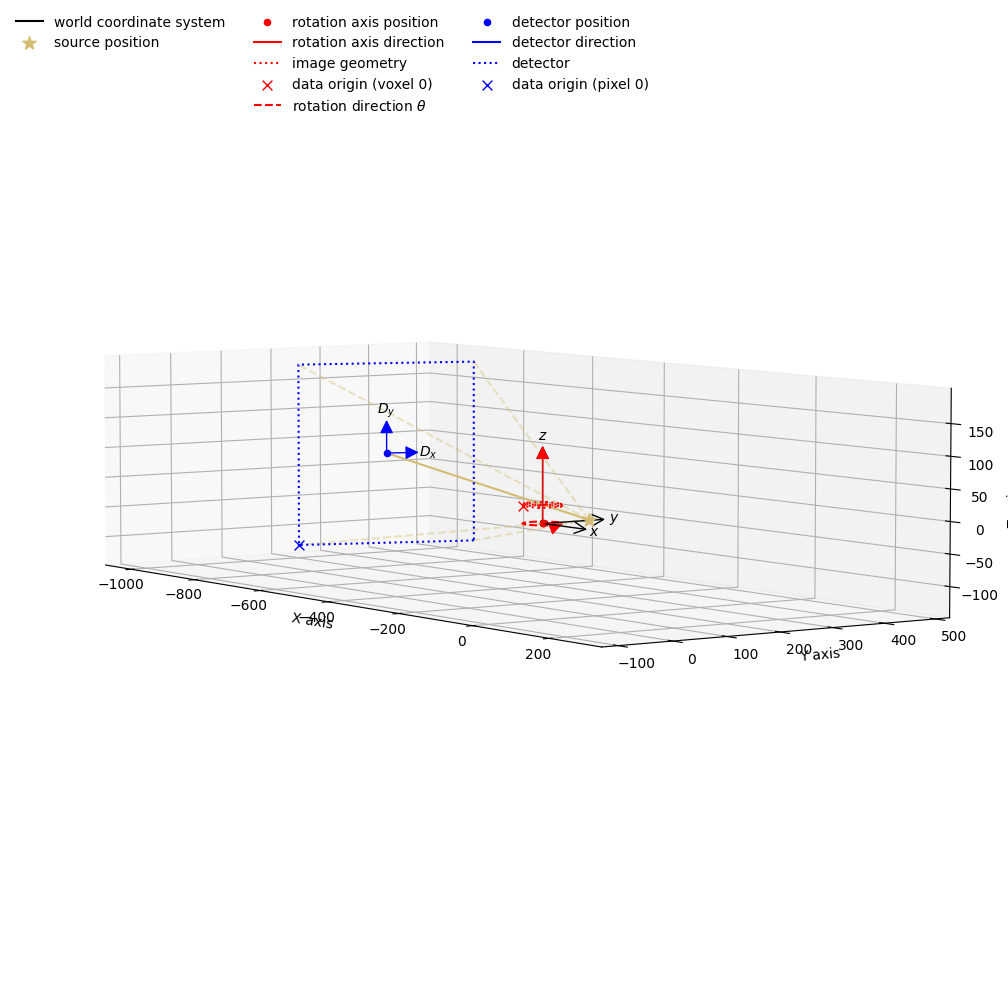

In [3]:
reader = NSIDataReader_(
    file_name='/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Demo_BabeRuth - PreReconstruction.nsipro',
    roi={'projection': (500,860,1)},
    positions_path='/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Radiographs-Demo_BabeRuth/positions.txt',
)

ig = reader.get_image_geometry(full_cover=False, remove_slices_per_side = 0)
print(ig)
show_geometry(reader.get_geometry(0), ig, grid=True, elevation=90, azimuthal = 0)
show_geometry(reader.get_geometry(700), ig, grid=True, elevation=5)


In [4]:
ad = reader.read()

{'axis_0': (500, 860, 1)}
Per-projection 3D Cone-beam tomography
System configuration:
	Number of projections: 360
	Source positions 0-9: [[-196.90942597, 165.22662671,  20.84843171],
 [-199.76303795, 161.76491856,  20.89012858],
 [-202.55580018, 158.25393525,  20.93182544],
 [-205.28686195, 154.69474626,  20.9735223 ],
 [-207.95539135, 151.08843575,  21.01521917],
 [-210.56057553, 147.43610223,  21.05691603],
 [-213.10162091, 143.73885826,  21.09861289],
 [-215.57775348, 139.99783003,  21.14030976],
 [-217.98821897, 136.21415711,  21.18200662],
 [-220.33228314, 132.38899204,  21.22370348]]
	Detector positions 0-9: [[ 766.40828541,-644.67669501,  16.83171671],
 [ 777.14412476,-631.69505967,  16.23400658],
 [ 787.52589733,-618.70709705,  16.56607844],
 [ 798.74547544,-604.14992287,  16.5970023 ],
 [ 808.90255153,-590.48281267,  17.41749517],
 [ 819.21927087,-576.0833929 ,  18.32807203],
 [ 828.71368776,-562.34300186,  17.91670389],
 [ 838.80428957,-547.17438691,  18.47184876],
 [ 847.78

In [5]:
ad.reorder(order='astra')

In [6]:
flat = tifffile.imread('/work3/s164564/CIL-Reader-Showcase/data/NSI-data/Radiographs-Demo_BabeRuth/Demo_BabeRuth-radio_04319.tif')
ad.array = ad.array / flat[:,None]
ad = TransmissionAbsorptionConverter(accelerated=False)(ad)

[[ 766.40828541 -644.67669501   16.83171671]
 [ 777.14412476 -631.69505967   16.23400658]
 [ 787.52589733 -618.70709705   16.56607844]
 ...
 [ 729.97774775 -685.66304476   35.79438496]
 [ 742.43118998 -672.15443236   35.94048882]
 [ 754.35079534 -658.74747365   35.20878768]]
[[-196.90942597  165.22662671   20.84843171]
 [-199.76303795  161.76491856   20.89012858]
 [-202.55580018  158.25393525   20.93182544]
 ...
 [-187.99227494  175.30563246   35.73421196]
 [-191.02314795  171.99801497   35.77590882]
 [-193.99583347  168.63800522   35.81760568]]


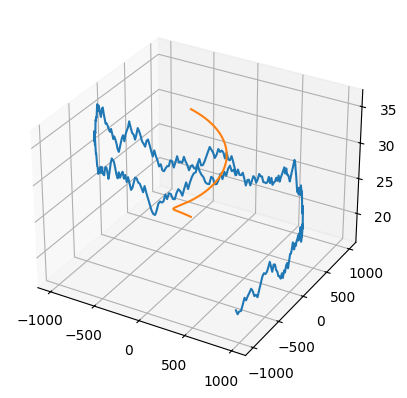

In [7]:
def get_det_position(ag):
    N_projs = len(ag.config.system.source)

    source_positions = np.array([ag.config.system.source[i].position for i in range(N_projs)])
    detector_positions = np.array([ag.config.system.detector[i].position for i in range(N_projs)])
    out = {}
    out['src_pos'] = source_positions
    out['det_pos'] = detector_positions



    return out

o = get_det_position(ad.geometry)
print(o['det_pos'])
print(o['src_pos'])



fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(o['det_pos'][:,0], o['det_pos'][:,1], o['det_pos'][:,2])
ax.plot(o['src_pos'][:,0], o['src_pos'][:,1], o['src_pos'][:,2])

plt.show()

In [8]:
device = "gpu"
A = ProjectionOperator(ig, ad.geometry, device)
initial = ig.allocate(0)
cgls = CGLS(initial=initial, operator=A, data=ad)

In [9]:
cgls.run(50, verbose=True)
recon = cgls.solution

  0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
# ad.reorder(order='astra')
# fbp = FBP(image_geometry=ig, acquisition_geometry=ad.geometry)
# fbp.set_input(ad)
# recon = fbp.get_output()

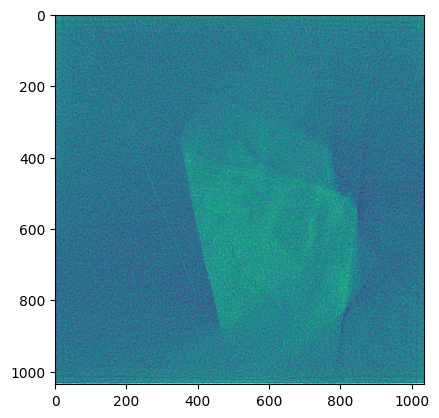

In [10]:
plt.figure()
plt.imshow(recon.as_array()[60])
plt.clim([-0.03,0.05])
plt.show()